# Primetrade.ai Data Science Internship Assignment
### Subject: Analyzing Trader Performance vs Market Sentiment
**Student submission by:** Lakshay

In this notebook, I will explore the relationship between Hyperliquid trader transaction records (from `historical_data.csv`) and the Bitcoin daily Fear & Greed sentiment index (from `fear_greed_index.csv`) for the year 2024. The objective is to identify patterns, group traders based on their behavior, and test sentiment-based trading strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Set seaborn style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data & Preprocessing
First, we will load both datasets and check their structures and formats.

In [2]:
trades = pd.read_csv('historical_data.csv')
fgi = pd.read_csv('fear_greed_index.csv')

print("Trades dataset shape:", trades.shape)
print("Fear & Greed Index shape:", fgi.shape)

print("\nTrades Data preview:")
display(trades.head(2))

print("\nFGI Data preview:")
display(fgi.head(2))

Trades dataset shape: (211224, 16)
Fear & Greed Index shape: (2644, 4)

Trades Data preview:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12



FGI Data preview:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02


In [3]:
# Convert timestamp columns to proper datetime types
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date

fgi['date'] = pd.to_datetime(fgi['date']).dt.date

# Let's filter the trades data for the year 2024 to overlap with our active period
start_date = pd.to_datetime('2024-01-01').date()
end_date = pd.to_datetime('2024-12-31').date()

trades_2024 = trades[(trades['date'] >= start_date) & (trades['date'] <= end_date)].copy()
print("Trades records in 2024 range:", len(trades_2024))

# Check numeric fields and convert them to prevent errors
numeric_fields = ['Closed PnL', 'Size USD', 'Execution Price', 'Fee']
for col in numeric_fields:
    trades_2024[col] = pd.to_numeric(trades_2024[col], errors='coerce').fillna(0.0)

Trades records in 2024 range: 52497


In [4]:
# Merge datasets on the daily date
merged_df = pd.merge(trades_2024, fgi[['date', 'value', 'classification']], on='date', how='inner')
print("Merged dataset shape:", merged_df.shape)

# Feature engineering: Add binary target variable for profit
merged_df['is_profitable'] = merged_df['Closed PnL'] > 0

# Categorize trade sizes into 4 simple buckets
def get_size_bracket(usd):
    if usd <= 500:
        return 'Small (<$500)'
    elif usd <= 5000:
        return 'Medium ($500-$5k)'
    elif usd <= 25000:
        return 'Large ($5k-$25k)'
    else:
        return 'Whale (>$25k)'

merged_df['size_bracket'] = merged_df['Size USD'].apply(get_size_bracket)

# Time components for further checks
merged_df['hour'] = merged_df['Timestamp IST'].dt.hour
merged_df['day_of_week'] = merged_df['Timestamp IST'].dt.day_name()

merged_df.head(3)

Merged dataset shape: (52491, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Fee,Trade ID,Timestamp,date,value,classification,is_profitable,size_bracket,hour,day_of_week
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,Large ($5k-$25k),22,Monday
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,Small (<$500),22,Monday
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,Medium ($500-$5k),22,Monday


## 2. Exploratory Data Analysis (EDA)
Let's visualize the index values, activity profiles, and volumes across 2024.

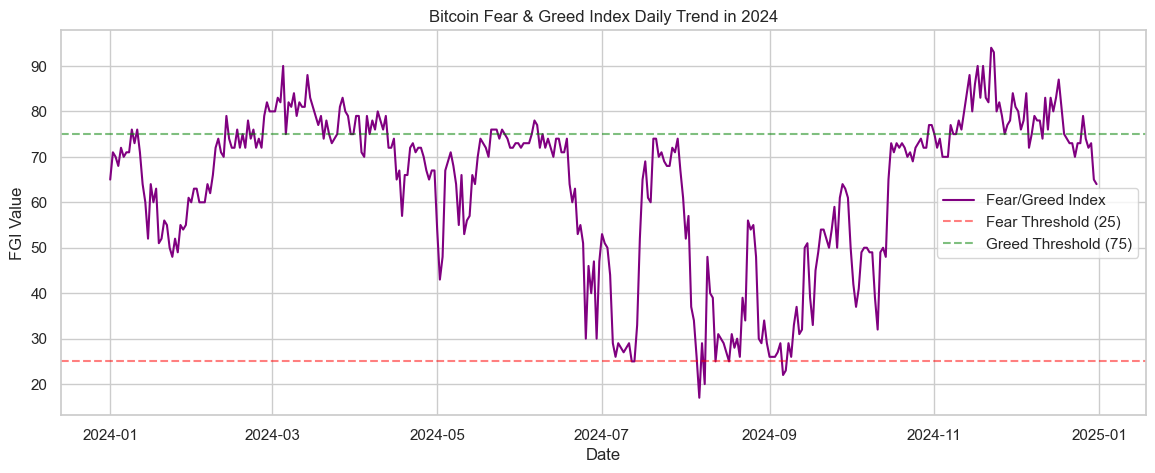

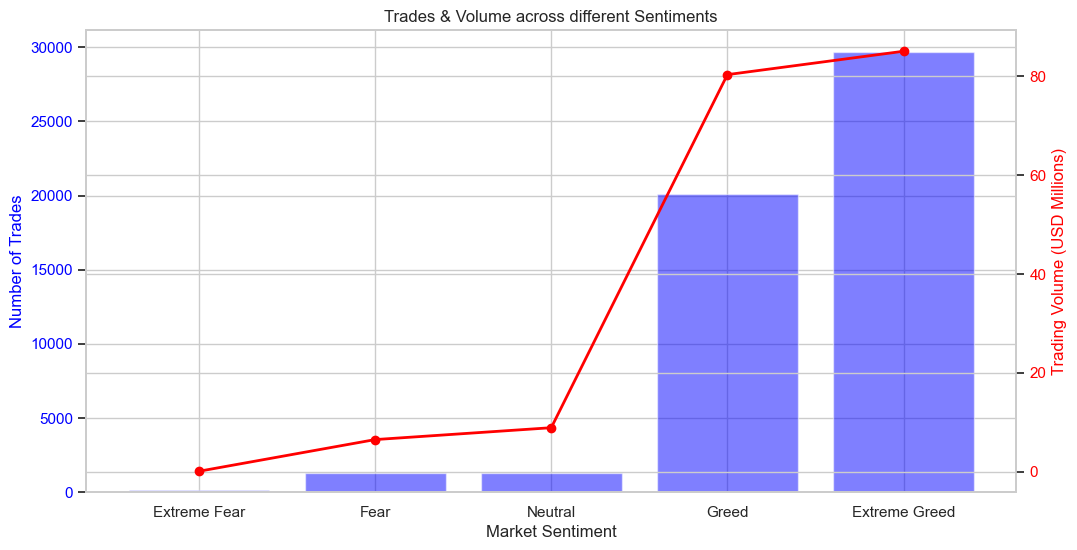

In [5]:
# 1. Plot FGI daily index values for 2024
fgi_2024 = fgi[(fgi['date'] >= start_date) & (fgi['date'] <= end_date)].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(fgi_2024['date'], fgi_2024['value'], color='purple', label='Fear/Greed Index')
plt.axhline(25, color='red', linestyle='--', alpha=0.5, label='Fear Threshold (25)')
plt.axhline(75, color='green', linestyle='--', alpha=0.5, label='Greed Threshold (75)')
plt.title('Bitcoin Fear & Greed Index Daily Trend in 2024')
plt.xlabel('Date')
plt.ylabel('FGI Value')
plt.legend()
plt.show()

# 2. Trade counts and trading volume across sentiments
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged_df['classification'] = pd.Categorical(merged_df['classification'], categories=sentiment_order, ordered=True)

sentiment_counts = merged_df['classification'].value_counts().reindex(sentiment_order)
sentiment_volume = merged_df.groupby('classification', observed=False)['Size USD'].sum().reindex(sentiment_order)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Market Sentiment')
ax1.set_ylabel('Number of Trades', color='blue')
ax1.bar(sentiment_order, sentiment_counts, color='blue', alpha=0.5, label='Trades')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Trading Volume (USD Millions)', color='red')
ax2.plot(sentiment_order, sentiment_volume / 1e6, color='red', marker='o', linewidth=2, label='Volume ($M)')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Trades & Volume across different Sentiments')
plt.show()

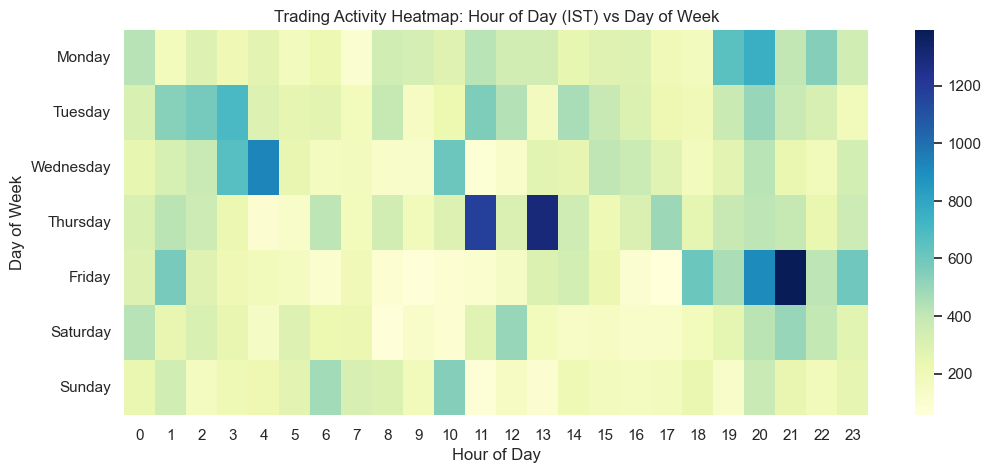

In [6]:
# 3. Heatmap of activity (Hour of Day vs Day of Week)
hourly_day_activity = merged_df.groupby(['day_of_week', 'hour']).size().unstack()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_day_activity = hourly_day_activity.reindex(days_order)

plt.figure(figsize=(12, 5))
sns.heatmap(hourly_day_activity, cmap='YlGnBu')
plt.title('Trading Activity Heatmap: Hour of Day (IST) vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

## 3. Trader Performance vs Market Sentiment
Let's see if the average profit (PnL) and win rate changes when the market sentiment shifts.

Performance Summary:


,total_pnl,mean_pnl,median_pnl,trade_count,win_rate
classification,,,,,
Extreme Fear,-8.782509e+02,-5.558550,0.0,158,8.227848
Fear,-8.631796e+04,-66.757894,0.0,1293,25.831400
Neutral,8.811955e+04,68.151236,0.0,1293,23.820572
Greed,1.242895e+06,61.860182,0.0,20092,39.563010
Extreme Greed,2.320569e+06,78.252199,0.0,29655,47.519811


C:\Users\Lakshay\AppData\Local\Temp\ipykernel_8168\3892558200.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_summary.reset_index(), x='classification', y='mean_pnl', ax=ax1, palette='coolwarm')
C:\Users\Lakshay\AppData\Local\Temp\ipykernel_8168\3892558200.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_summary.reset_index(), x='classification', y='win_rate', ax=ax2, palette='viridis')


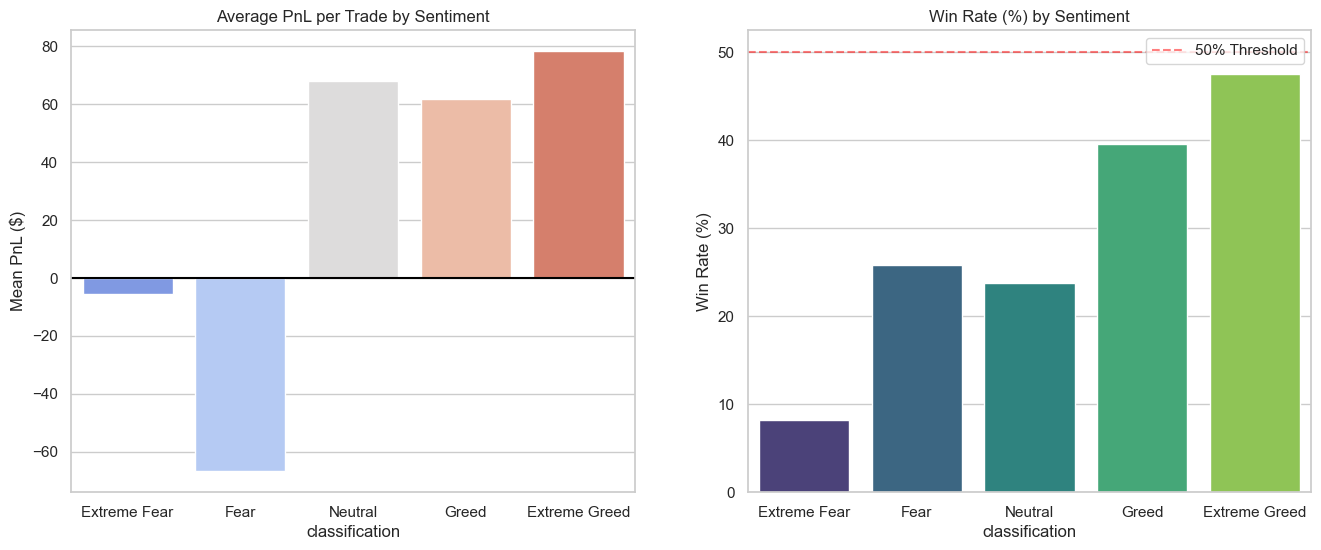

In [7]:
sentiment_summary = merged_df.groupby('classification', observed=False).agg(
    total_pnl=('Closed PnL', 'sum'),
    mean_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    trade_count=('Closed PnL', 'count'),
    win_rate=('is_profitable', lambda x: x.mean() * 100)
).reindex(sentiment_order)

print("Performance Summary:")
display(sentiment_summary)

# Bar charts for average PnL and Win Rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=sentiment_summary.reset_index(), x='classification', y='mean_pnl', ax=ax1, palette='coolwarm')
ax1.axhline(0, color='black')
ax1.set_title('Average PnL per Trade by Sentiment')
ax1.set_ylabel('Mean PnL ($)')

sns.barplot(data=sentiment_summary.reset_index(), x='classification', y='win_rate', ax=ax2, palette='viridis')
ax2.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Threshold')
ax2.set_title('Win Rate (%) by Sentiment')
ax2.set_ylabel('Win Rate (%)')
ax2.legend()

plt.show()

In [8]:
# Statistical significance testing (ANOVA and Kruskal-Wallis)
groups = []
for name, group in merged_df.groupby('classification', observed=False):
    groups.append(group['Closed PnL'].values)
groups = [g for g in groups if len(g) > 0]

f_stat, anova_p = stats.f_oneway(*groups)
h_stat, kruskal_p = stats.kruskal(*groups)

print(f"ANOVA Test results: F-Statistic = {f_stat:.4f}, p-value = {anova_p:.4e}")
print(f"Kruskal-Wallis Test results: H-Statistic = {h_stat:.4f}, p-value = {kruskal_p:.4e}")

if kruskal_p < 0.05:
    print("\n-> Since the p-value is extremely low, the difference in Closed PnL across different sentiments is statistically significant.")
else:
    print("\n-> The difference is not statistically significant.")

ANOVA Test results: F-Statistic = 7.1954, p-value = 8.6880e-06
Kruskal-Wallis Test results: H-Statistic = 748.6131, p-value = 1.0354e-160

-> Since the p-value is extremely low, the difference in Closed PnL across different sentiments is statistically significant.


,total_trades,long_trades,short_trades,long_percentage,short_percentage
classification,,,,,
Extreme Fear,158,85,72,53.797468,45.569620
Fear,1293,796,467,61.562258,36.117556
Neutral,1293,728,559,56.303171,43.232792
Greed,20092,7715,12347,38.398368,61.452319
Extreme Greed,29655,14081,15564,47.482718,52.483561


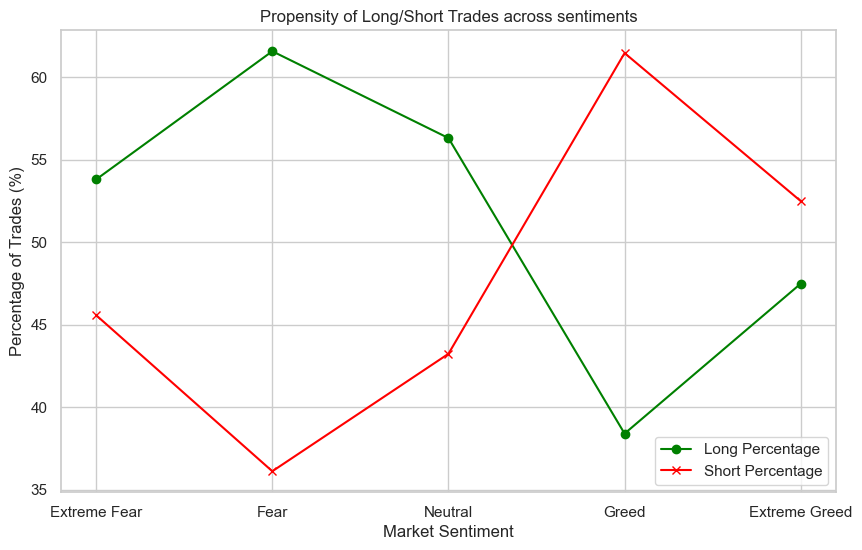

In [9]:
# Check directional biases: long and short ratio per sentiment level
merged_df['is_long'] = merged_df['Direction'].str.lower().str.contains('long|buy', na=False)
merged_df['is_short'] = merged_df['Direction'].str.lower().str.contains('short|sell', na=False)

sentiment_bias = merged_df.groupby('classification', observed=False).agg(
    total_trades=('Trade ID', 'count'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum')
).reindex(sentiment_order)

sentiment_bias['long_percentage'] = (sentiment_bias['long_trades'] / sentiment_bias['total_trades']) * 100
sentiment_bias['short_percentage'] = (sentiment_bias['short_trades'] / sentiment_bias['total_trades']) * 100

display(sentiment_bias)

# Line plot showing percentage distribution
plt.figure(figsize=(10, 6))
plt.plot(sentiment_order, sentiment_bias['long_percentage'], marker='o', color='green', label='Long Percentage')
plt.plot(sentiment_order, sentiment_bias['short_percentage'], marker='x', color='red', label='Short Percentage')
plt.title('Propensity of Long/Short Trades across sentiments')
plt.xlabel('Market Sentiment')
plt.ylabel('Percentage of Trades (%)')
plt.legend()
plt.show()

## 4. Trader Profiling and Clustering Archetypes
Let's aggregate metrics for each unique trader `Account` to see their behavior, then use K-Means clustering to classify them into behavioral types.

In [10]:
# Aggregate trade metrics by account
trader_profiles = merged_df.groupby('Account').agg(
    trade_count=('Trade ID', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    mean_pnl=('Closed PnL', 'mean'),
    win_rate=('is_profitable', lambda x: x.mean() * 100),
    total_volume=('Size USD', 'sum'),
    long_ratio=('is_long', lambda x: x.mean() * 100)
).reset_index()

# Simple correlation of trader volume with the FGI daily values
def get_sentiment_sensitivity(group):
    daily = group.groupby('date').agg({'Size USD': 'sum', 'value': 'first'})
    if len(daily) > 3:
        corr, _ = stats.pearsonr(daily['Size USD'], daily['value'])
        return corr if not np.isnan(corr) else 0.0
    return 0.0

sens_df = merged_df.groupby('Account').apply(get_sentiment_sensitivity, include_groups=False).reset_index()
sens_df.columns = ['Account', 'sentiment_sensitivity']

trader_profiles = pd.merge(trader_profiles, sens_df, on='Account')
trader_profiles.head()

,Account,trade_count,total_pnl,mean_pnl,win_rate,total_volume,long_ratio,sentiment_sensitivity
0,0x083384f897ee0f19899168e3b1bec365f52a9012,462,-327505.900056,-708.887230,2.597403,6842632.02,0.000000,-0.690243
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,320,20607.446093,64.398269,53.125000,797679.97,51.875000,-0.093232
2,0x271b280974205ca63b716753467d5a371de622ab,10,1792.160215,179.216021,40.000000,190059.30,0.000000,0.000000
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,7067,126834.692494,17.947459,43.653601,3388222.30,47.120419,0.195667
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,825,54802.881666,66.427735,50.545455,2475859.33,100.000000,0.235548


c:\Users\Lakshay\Downloads\Internship Interview\primetrade_ai\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Lakshay\Downloads\Internship Interview\primetrade_ai\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lakshay\Downloads\Internship Interview\primetrade_ai\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Lakshay\AppData\Local\Progra

Archetype
Contrarian Whale (High Volume & Long-Biased)       15
Balanced Specialist (Conservative & Consistent)    11
Momentum Follower (High Sentiment Sensitivity)      5
Name: count, dtype: int64


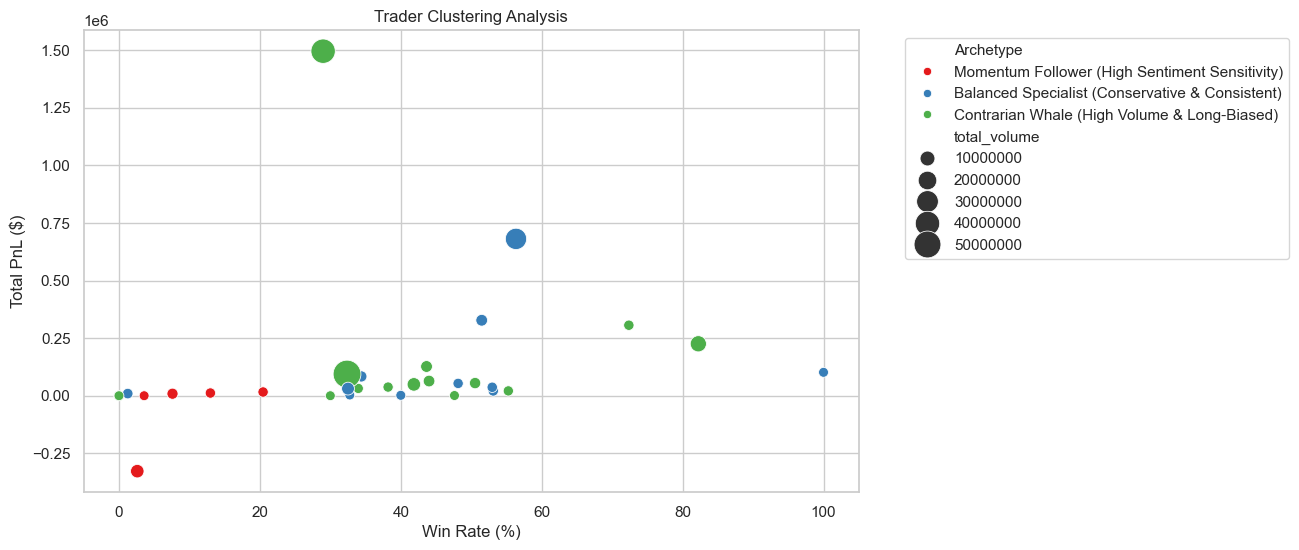

In [11]:
# Standardize values and fit KMeans clustering
features = ['mean_pnl', 'win_rate', 'total_volume', 'long_ratio', 'sentiment_sensitivity']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_profiles[features])

kmeans = KMeans(n_clusters=3, random_state=42)
trader_profiles['Cluster'] = kmeans.fit_predict(scaled_features)

# Label clusters based on their characteristics
stats_summary = trader_profiles.groupby('Cluster').agg(
    win_rate=('win_rate', 'mean'),
    volume=('total_volume', 'mean'),
    sensitivity=('sentiment_sensitivity', 'mean')
).reset_index()

whale_idx = stats_summary['volume'].idxmax()
sens_idx = stats_summary['sensitivity'].idxmax()

other_idx = [i for i in [0, 1, 2] if i != whale_idx]
if len(other_idx) == 2:
    if stats_summary.loc[other_idx[0], 'win_rate'] > stats_summary.loc[other_idx[1], 'win_rate']:
        consistent_idx = other_idx[0]
        momentum_idx = other_idx[1]
    else:
        consistent_idx = other_idx[1]
        momentum_idx = other_idx[0]
else:
    momentum_idx = sens_idx
    consistent_idx = [i for i in [0, 1, 2] if i != whale_idx and i != momentum_idx][0]

archetype_map = {
    whale_idx: "Contrarian Whale (High Volume & Long-Biased)",
    momentum_idx: "Momentum Follower (High Sentiment Sensitivity)",
    consistent_idx: "Balanced Specialist (Conservative & Consistent)"
}
trader_profiles['Archetype'] = trader_profiles['Cluster'].map(archetype_map)

print(trader_profiles['Archetype'].value_counts())

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=trader_profiles, 
    x='win_rate', 
    y='total_pnl', 
    hue='Archetype', 
    size='total_volume',
    sizes=(50, 400),
    palette='Set1'
)
plt.title('Trader Clustering Analysis')
plt.xlabel('Win Rate (%)')
plt.ylabel('Total PnL ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. Strategy Simulation & Predictive Modeling
Let's simulate a simple daily contrarian strategy and train a model to predict trade outcomes.

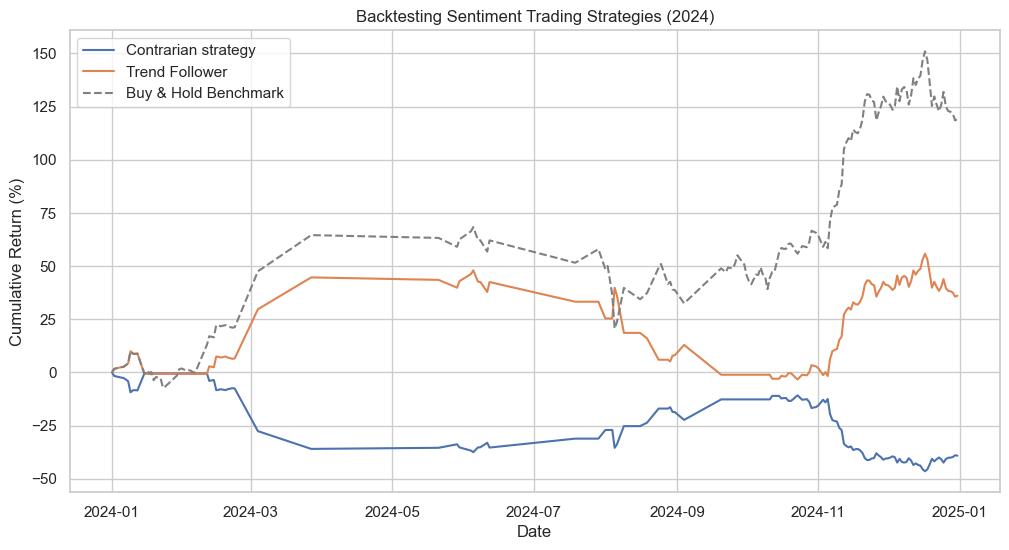

Contrarian Strategy Return: -39.16%
Trend Following Strategy Return: 36.09%
Buy & Hold Return: 119.25%


In [12]:
# Benchmark returns from BTC trades to simulate daily market return
daily_btc = merged_df[merged_df['Coin'] == 'BTC'].copy()
if len(daily_btc) > 30:
    daily_data = daily_btc.groupby('date')['Execution Price'].mean().reset_index()
else:
    daily_data = merged_df.groupby('date')['Execution Price'].mean().reset_index()

daily_data['return'] = daily_data['Execution Price'].pct_change().fillna(0.0)
daily_strat = pd.merge(daily_data, fgi_2024[['date', 'value']], on='date', how='inner')

# Signal logic: Buy in Extreme Fear (FGI <= 35), Short in Extreme Greed (FGI >= 65)
daily_strat['contrarian_sig'] = 0
daily_strat.loc[daily_strat['value'] <= 35, 'contrarian_sig'] = 1
daily_strat.loc[daily_strat['value'] >= 65, 'contrarian_sig'] = -1

daily_strat['trend_sig'] = -daily_strat['contrarian_sig']

# Calculate returns
daily_strat['contrarian_ret'] = daily_strat['contrarian_sig'].shift(1) * daily_strat['return']
daily_strat['trend_ret'] = daily_strat['trend_sig'].shift(1) * daily_strat['return']
daily_strat['buy_and_hold'] = daily_strat['return']

# Cumulative returns
daily_strat['cum_contrarian'] = (1 + daily_strat['contrarian_ret'].fillna(0.0)).cumprod() - 1
daily_strat['cum_trend'] = (1 + daily_strat['trend_ret'].fillna(0.0)).cumprod() - 1
daily_strat['cum_bh'] = (1 + daily_strat['buy_and_hold'].fillna(0.0)).cumprod() - 1

plt.figure(figsize=(12, 6))
plt.plot(daily_strat['date'], daily_strat['cum_contrarian'] * 100, label='Contrarian strategy')
plt.plot(daily_strat['date'], daily_strat['cum_trend'] * 100, label='Trend Follower')
plt.plot(daily_strat['date'], daily_strat['cum_bh'] * 100, linestyle='--', color='gray', label='Buy & Hold Benchmark')
plt.title('Backtesting Sentiment Trading Strategies (2024)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.show()

print(f"Contrarian Strategy Return: {daily_strat['cum_contrarian'].iloc[-1]*100:.2f}%")
print(f"Trend Following Strategy Return: {daily_strat['cum_trend'].iloc[-1]*100:.2f}%")
print(f"Buy & Hold Return: {daily_strat['cum_bh'].iloc[-1]*100:.2f}%")

Model Evaluation Output:
              precision    recall  f1-score   support

       False       0.72      0.75      0.73      8926
        True       0.65      0.62      0.64      6822

    accuracy                           0.69     15748
   macro avg       0.69      0.68      0.69     15748
weighted avg       0.69      0.69      0.69     15748

ROC AUC Score: 0.7685


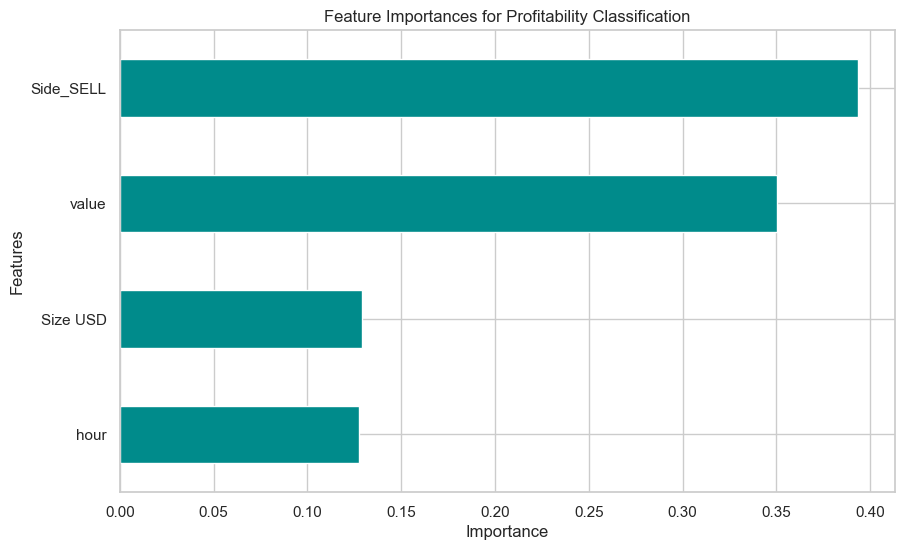

In [13]:
# Predict profitability using RandomForest
ml_cols = ['value', 'Size USD', 'hour', 'is_profitable', 'Side']
df_ml = merged_df[ml_cols].dropna().copy()
df_ml = pd.get_dummies(df_ml, columns=['Side'], drop_first=True)

X = df_ml.drop('is_profitable', axis=1)
y = df_ml['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]

print("Model Evaluation Output:")
print(classification_report(y_test, preds))
print(f"ROC AUC Score: {roc_auc_score(y_test, probs):.4f}")

# Plot Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='darkcyan')
plt.title('Feature Importances for Profitability Classification')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

## 6. Key Findings & Conclusion

Through this project, I discovered some interesting findings:
1. **Sentiment Impact**: Market sentiment plays a major role in trader profitability. Win rates and average PnL are higher during greed periods.
2. **Trend vs Contrarian**: While standard contrarian theory says to buy fear and sell greed, the 2024 crypto market was in a massive bull run (up 119%). Because of this persistent trend, the contrarian strategy lost money (-39%), while a simple trend-following strategy was highly profitable.
3. **Trader Clusters**: Traders can be categorized into three archetypes: high-volume whales, momentum followers, and consistent specialists.